In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt



# Data Loading

In [15]:
df = pd.read_csv("data/owid-co2-data.csv")

df

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957


In [16]:
print(df.head(10))

       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   
5  Afghanistan  1755      AFG         NaN  NaN         0.0   
6  Afghanistan  1756      AFG         NaN  NaN         0.0   
7  Afghanistan  1757      AFG         NaN  NaN         0.0   
8  Afghanistan  1758      AFG         NaN  NaN         0.0   
9  Afghanistan  1759      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN    

In [17]:
print(df.columns)

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

In [18]:
print(df.dtypes)

country                         object
year                             int64
iso_code                        object
population                     float64
gdp                            float64
                                ...   
temperature_change_from_n2o    float64
total_ghg                      float64
total_ghg_excluding_lucf       float64
trade_co2                      float64
trade_co2_share                float64
Length: 79, dtype: object


In [19]:
print(df.shape)

(50411, 79)


## IMP columns

1) co2 -> it represents Annual CO₂ emissions

2) co2_per_capita -> CO₂ emissions per capita
3) methane -> Annual methane emissions including land use
4) nitrous_oxide -> Annual nitrous oxide emissions including land use
5) total_ghg -> Annual greenhouse gas emissions including land use
6) year -> 	Year
7) country -> Country

## Data Profiling



In [20]:
null_percent = (df.isnull().sum()/len(df))*100

In [21]:
null_percent.to_frame("NULL %")

,NULL %
country,0.000000
year,0.000000
iso_code,15.732677
population,18.337268
gdp,69.746682
...,...
temperature_change_from_n2o,24.064192
total_ghg,24.322073
total_ghg_excluding_lucf,24.990577
trade_co2,90.652834


In [22]:
important_columns = [
    "co2",
    "co2_per_capita",
    "methane",
    "nitrous_oxide",
    "total_ghg"
]

country coverage 

Group the dataset by country. For each country, check how many non-missing values exist in the important GHG columns. Calculate the average completeness percentage across those columns. Then sort countries from most complete to least complete.

In [23]:
country_coverage = (
   df.groupby("country")[important_columns].apply(lambda data:data.notna().mean().mean()*100).sort_values(ascending=False))

country_coverage.head(20)

country
Mexico         98.628571
Cuba           98.628571
Uruguay        98.628571
Brazil         98.628571
Colombia       98.628571
Argentina      98.628571
Peru           98.628571
Romania        98.171429
Switzerland    98.171429
Chile          98.011050
Czechia        97.714286
Italy          97.714286
Slovakia       97.714286
Finland        97.714286
Denmark        97.692308
Russia         97.318436
Ukraine        97.318436
Kyrgyzstan     97.318436
Kazakhstan     97.318436
Latvia         97.318436
dtype: float64

year coverage 

Which years have the most complete greenhouse gas reporting

In [24]:
year_coverage = (df.groupby("year")[important_columns].apply(lambda data:data.notna().mean().mean()*100).sort_values(ascending=False))
year_coverage.head(20)

year
2024    89.291339
2009    89.291339
1994    89.291339
1995    89.291339
1996    89.291339
1997    89.291339
1998    89.291339
1999    89.291339
2000    89.291339
2001    89.291339
2002    89.291339
2003    89.291339
2004    89.291339
2005    89.291339
2006    89.291339
2007    89.291339
2008    89.291339
2017    89.291339
2011    89.291339
2012    89.291339
dtype: float64

## observation 
Recent years show better reporting coverage.

Many historical records have missing methane and nitrous oxide values.

Developed countries generally exhibit more complete datasets.

In [25]:
df[["country","iso_code"]].drop_duplicates()

,country,iso_code
0,Afghanistan,AFG
275,Africa,NaN
550,Africa (GCP),NaN
725,Albania,ALB
900,Algeria,DZA
...,...,...
49337,Wallis and Futuna,WLF
49511,World,NaN
49786,Yemen,YEM
49961,Zambia,ZMB


In [26]:
filtered_dataset = (df.dropna(subset=["iso_code"]))

project_countries = [
    "China",
    "United States",
    "India",
    "Russia",
    "Japan",
    "Germany",
    "Brazil",
    "United Kingdom",
    "South Africa",
    "Australia"
]

filtered_dataset = df[
    (df["year"] >= 1990)
    &
    (df["country"].isin(project_countries))
].copy()
filtered_dataset

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
3644,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
3645,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
3646,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3647,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
3648,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48003,United States,2020,USA,339436156.0,1.802736e+13,40.688,0.120,4689.954,-545.958,-10.427,...,30.237,18.090,0.037,0.238,0.286,0.011,5758.456,5309.856,413.131,8.809
48004,United States,2021,USA,340161438.0,1.909938e+13,41.312,0.121,5020.111,330.157,7.040,...,31.844,17.980,0.037,0.240,0.288,0.011,6131.129,5675.305,469.552,9.353
48005,United States,2022,USA,341534041.0,1.949317e+13,41.884,0.123,5055.403,35.292,0.703,...,30.882,17.870,0.038,0.242,0.291,0.011,6201.504,5728.265,510.586,10.100
48006,United States,2023,USA,343477330.0,NaN,40.636,0.118,4918.407,-136.996,-2.710,...,31.847,17.759,0.038,0.245,0.294,0.011,6078.455,5606.243,513.252,10.435


Rows with missing ISO country codes were removed because they represent aggregate regions (e.g., World, Asia, Europe) rather than individual countries. 
The analysis focuses on data after 1990.

## EXPLANATORY DATA ANALYSIS

1) PLOT A LINE CHART OF GLOBAL CO2 EMISSION FROM 1990 TO THE LATEST YEAR AVAILABLE 

In [27]:
world_data = df[(df["country"]=="World")&(df["year"]>=1990) ]

In [28]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

creates a blank canvas

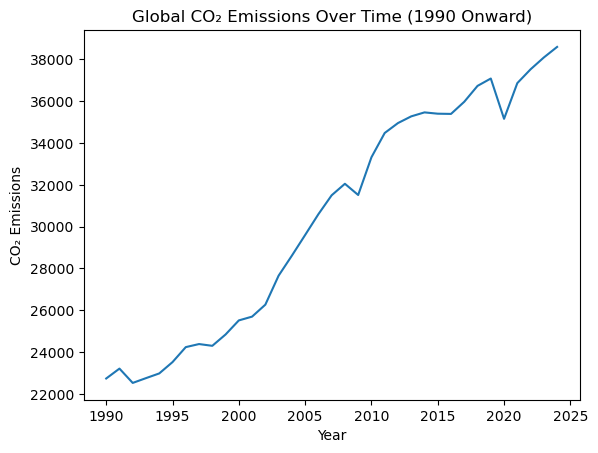

In [29]:
plt.plot(world_data["year"],world_data["co2"])
plt.title("Global CO₂ Emissions Over Time (1990 Onward)")

plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.show()

## observation
1) Global CO₂ emissions increased steadily from 1990 onward, showing a clear long-term upward trend.
2) Small declines are visible around 2009 and 2020, but emissions quickly recovered and reached new highs afterward.
3) Overall, global emissions have continued to grow despite temporary setbacks

2) PLOT A MULTILINE CHART COMPARING CO2 EMISSION TRENDS FOR THE TOP 5 EMITTING COUNTRIES 

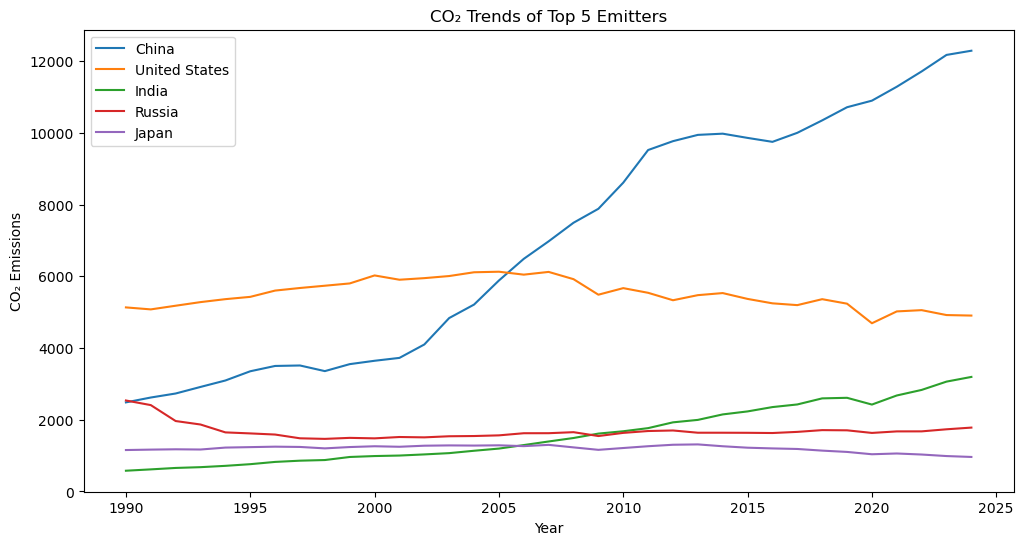

In [30]:
top_emitters = [
    "China",
    "United States",
    "India",
    "Russia",
    "Japan"
]

plt.figure(figsize=(12,6))

for country in top_emitters:

    country_data = filtered_dataset[
        filtered_dataset["country"] == country
    ]

    plt.plot(
        country_data["year"],
        country_data["co2"],
        label=country
    )

plt.title(
    "CO₂ Trends of Top 5 Emitters"
)

plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.legend()

plt.show()

## observation
1) China's CO₂ emissions increased rapidly and became the highest among all countries.
2) The United States shows a gradual decline, while India displays steady growth.
3) Russia and Japan remained relatively stable throughout the period.

3) PLOT A STACKED BAR OR AREA CHART SHOWING SHARE OF TOTAL GLOBAL GHG BY GAS TYPE (CO2, CH4 , N2O) PER DECADE : 1990S , 2000S , 2010S , 2020S 

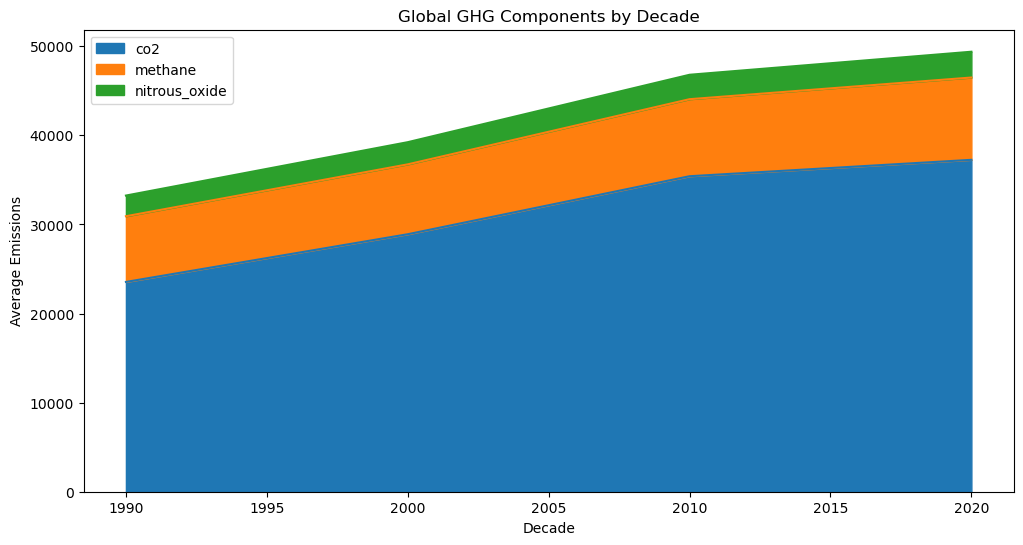

In [31]:
world_data = world_data.copy()

world_data["decade"] = (world_data["year"] // 10) * 10
decade_data = (world_data.groupby("decade")[["co2","methane","nitrous_oxide"]].mean())
decade_data.plot(kind="area",stacked=True,figsize=(12,6))

plt.title("Global GHG Components by Decade")

plt.xlabel("Decade")
plt.ylabel("Average Emissions")

plt.show()

## observation
1) CO₂ contributes the largest share of global greenhouse gas emissions in every decade.
2) Methane is the second-largest contributor, while nitrous oxide remains comparatively smaller.
3) Emissions from all three gases show an increasing trend over time.

In [32]:
filtered_dataset.to_csv(
    "data/filtered_dataset.csv",
    index=False
)